In [15]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow info logs

import keras
from keras.models import Model
from keras.layers import Dense, Input, Concatenate
from keras.optimizers import Adam
import tensorflow as tf
from sklearn.feature_selection import mutual_info_regression

import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors, KDTree as skKDTree
from scipy.special import digamma
from scipy.spatial import KDTree as spKDTree

import pisces.data_sets as pds

In [55]:
np.log(2)

0.6931471805599453

In [58]:
# Define correlated normal generator
def generate_correlated_normals(shape, R):
    mean = np.zeros(2)
    cov = [[1, R], [R, 1]]
    samples = np.random.multivariate_normal(mean, cov, size=shape[0])
    return samples[:, 0].reshape(-1, 1), samples[:, 1].reshape(-1, 1)

# Generate data
R = 0.5
X, Y = generate_correlated_normals((10000, ), R)


scaler = StandardScaler()
X = scaler.fit_transform(X)
Y = scaler.fit_transform(Y)

# Calculate MI
print("Theoretical MI:", -0.5 * np.log(1 - R**2))
print("sklearn:", mutual_info_regression(X, Y, n_neighbors=3))


Theoretical MI: 0.14384103622589045
sklearn: [0.14495421]


/opt/homebrew/Caskroom/miniforge/base/envs/pisces/lib/python3.11/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [17]:



def _compute_mi_cc(x, y, n_neighbors):
    """Compute mutual information between two continuous variables.
    !!! This is taken from sklearn's source code.
    https://github.com/scikit-learn/scikit-learn/blob/15eb9f30c77ec8166a0135ca14b8de7fdfe15b91/sklearn/feature_selection/_mutual_info.py#L20

    Parameters
    ----------
    x, y : ndarray, shape (n_samples,)
        Samples of two continuous random variables, must have an identical
        shape.

    n_neighbors : int
        Number of nearest neighbors to search for each point, see [1]_.

    Returns
    -------
    mi : float
        Estimated mutual information in nat units. If it turned out to be
        negative it is replaced by 0.

    Notes
    -----
    True mutual information can't be negative. If its estimate by a numerical
    method is negative, it means (providing the method is adequate) that the
    mutual information is close to 0 and replacing it by 0 is a reasonable
    strategy.

    References
    ----------
    .. [1] A. Kraskov, H. Stogbauer and P. Grassberger, "Estimating mutual
           information". Phys. Rev. E 69, 2004.
    """
    n_samples = x.size

    # x = x.reshape((-1, 1))
    y = y.reshape((-1, 1))
    xy = np.hstack((x, y))

    # Here we rely on NearestNeighbors to select the fastest algorithm.
    nn = NearestNeighbors(metric="chebyshev", n_neighbors=n_neighbors)

    nn.fit(xy)
    radius = nn.kneighbors()[0]
    radius = np.nextafter(radius[:, -1], 0)

    # KDTree is explicitly fit to allow for the querying of number of
    # neighbors within a specified radius
    kd = skKDTree(x, metric="chebyshev")
    nx = kd.query_radius(x, radius, count_only=True, return_distance=False)
    nx = np.array(nx) - 1.0

    kd = skKDTree(y, metric="chebyshev")
    ny = kd.query_radius(y, radius, count_only=True, return_distance=False)
    ny = np.array(ny) - 1.0

    mi = (
        digamma(n_samples)
        + digamma(n_neighbors)
        - np.mean(digamma(nx + 1))
        - np.mean(digamma(ny + 1))
    )

    return max(0, mi)

In [20]:
_compute_mi_cc(X, Y, 5)

0.15038884194171942

In [27]:


def mutual_information_ksg(X, Y, k=5):
    """
    Estimate the mutual information between multi-dimensional variables X and Y 
    using the Kraskov-Stögbauer-Grassberger (KSG) estimator (KSG1).
    """
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    N = X.shape[0]
    if Y.shape[0] != N:
        raise ValueError("X and Y must have the same number of samples.")
    d_x = X.shape[1] if X.ndim > 1 else 1
    d_y = Y.shape[1] if Y.ndim > 1 else 1

    # Build KD Trees
    XY = np.hstack((X, Y))
    xy_tree = spKDTree(XY)
    x_tree = spKDTree(X)
    y_tree = spKDTree(Y)

    # Find the distance to the k-th nearest neighbor in the joint space
    distances, _ = xy_tree.query(XY, k=k+1, p=np.inf)  # k+1 because the point itself is included
    kth_dist = distances[:, k]

    # Count neighbors in X and Y within the radius defined by the k-th NN distance
    n_x = np.array([len(x_tree.query_ball_point(x, r=kth_dist[i] - 1e-10)) - 1 for i, x in enumerate(X)])
    n_y = np.array([len(y_tree.query_ball_point(y, r=kth_dist[i] - 1e-10)) - 1 for i, y in enumerate(Y)])

    # Apply the KSG estimator formula
    MI = digamma(k) + digamma(N) - np.mean(digamma(n_x + 1) + digamma(n_y + 1))
    return MI

In [34]:
mutual_information_ksg(X, Y, k=5)

0.15038884194171942

In [35]:
np.log2(np.exp(mutual_information_ksg(X, Y, k=5)))

0.21696523647435273

In [40]:
x2 = np.random.randn(10000, 2)
y2 = (x2[:, 0] + x2[:, 1] + np.random.randn(10000) * 0.1).reshape(-1, 1)

# print("sklearn:", mutual_info_regression(x2, y2, n_neighbors=5))

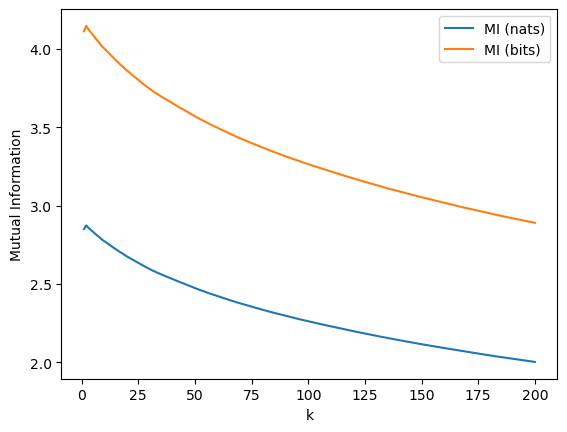

In [45]:
mi_nats_list = []
mi_bits_list = []

ks = list(range(1, 201))

for k in ks:
    mi_nats = mutual_information_ksg(x2, y2, k=k)
    # print("KSG (k=%d):" % k, mi_nats, "nats")
    mi_bits = np.log2(np.exp(mi_nats))
    # print("KSG (k=%d):" % k, mi_bits, "bits")
    mi_nats_list.append(mi_nats)
    mi_bits_list.append(mi_bits)


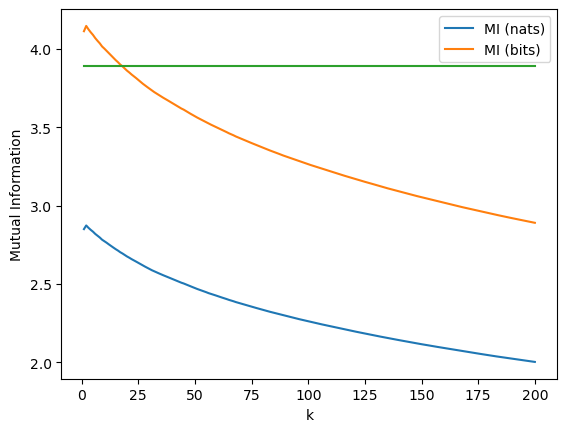

In [51]:
plt.plot(ks, mi_nats_list, label='MI (nats)')
plt.plot(ks, mi_bits_list, label='MI (bits)')
plt.plot(ks, np.ones_like(ks) * 3.89)
plt.xlabel('k')
plt.ylabel('Mutual Information')
plt.legend()
plt.show()


In [53]:
mi_bits_arr = np.array(mi_bits_list)
np.where(mi_bits_arr < 3.9)[0]

array([ 16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,
        29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
        42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,
        55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,
        68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,
        81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,
        94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106,
       107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119,
       120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132,
       133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145,
       146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158,
       159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171,
       172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184,
       185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 19

In [54]:
mutual_information_ksg(x2, y2, k=15)

2.7222593621604965

# Regression Mutual Info

In [60]:

# Load the dataset
DATA_DIR = '../../data'
sets = pds.DataSetObject.find_data_sets(DATA_DIR)


In [61]:
sets.keys()

dict_keys(['hybrid_motion', 'hf_disordered', 'eric_exports', 'walch_et_al'])

In [62]:
worst_val_auc_id = '9106476'
best_val_auc_id = '3997827'

In [63]:
walch = sets['walch_et_al']
walch.parse_data_sets()

In [64]:
from pisces.utils import build_ADS


w0_id = best_val_auc_id
w0_acc = walch.get_feature_data('accelerometer', w0_id)
w0_psg = walch.get_feature_data('psg', w0_id)
w0_activity_time, w0_activity = build_ADS(w0_acc, resample_hz=50, bin_size_seconds=30)

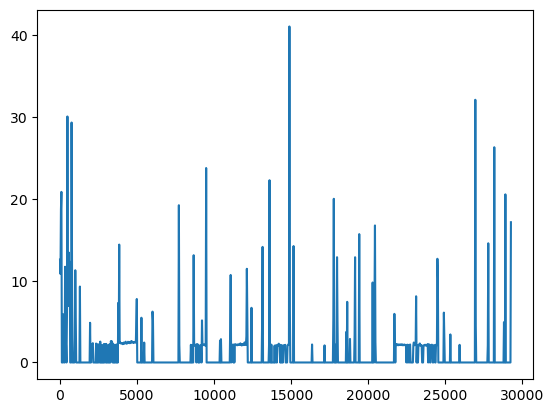

In [65]:

plt.plot(w0_activity_time, w0_activity)

In [66]:
def rolling_window(x: np.ndarray, window_size: int, step_size: int=1, axis: int = 0) -> np.ndarray:
    """
    Create a rolling window view of the input array.
    """
    return np.lib.stride_tricks.sliding_window_view(x, window_shape=(window_size,), axis=0)[::step_size]

def stretch_to_range(x, low, high):
    """
    Stretch the input array to the range [low, high].
    """
    return (x - np.min(x)) / (np.max(x) - np.min(x)) * (high - low) + low

In [67]:
sw_psg = np.where(w0_psg[:, 1] > 0, 1, w0_psg[:, 1])

In [68]:
WINDOW = 61
activity_01 = stretch_to_range(w0_activity, 0, 1)
wrapped_activity = rolling_window(activity_01, WINDOW)

wrapped_time = rolling_window(w0_activity_time, WINDOW)

In [69]:
wrapped_activity.shape

(916, 61)

In [70]:
w0_activity.shape

(976,)

# KSG Estimator for MI
The sklearn function `mutual_info_regression` uses the KSG estimator for mutual information. However, the implementation parallizes along the input vector `X` and treats each as a separate query against the (strictly 1-dimensional) `y`. However, for a convolutional kernel, the input vector `X` is the entire sub-vector of the original that's covered by the kernel. We go back to the original publication and use the ideas, making a k-Nearest Neighbor algorithm that does not make these assumptions.

In [71]:
type(w0_psg)

polars.dataframe.frame.DataFrame

In [72]:
w0_psg = w0_psg.to_numpy()

In [73]:
type(sw_psg)

numpy.ndarray

In [74]:
wrapped_activity.shape

(916, 61)

In [80]:
sw_psg_comp = sw_psg[WINDOW // 2: -WINDOW // 2 + 1]

In [84]:
def wrap_io(x_in, y_in, label_window_frac: float, window_size):
    x_out = rolling_window(x_in, window_size)
    y_out = y_in[window_size // 2: -window_size // 2 + 1]
    return x_out, y_out

7 1066528
7 1360686
7 4018081
ID 7749105 not found in walch_et_al
7 7749105


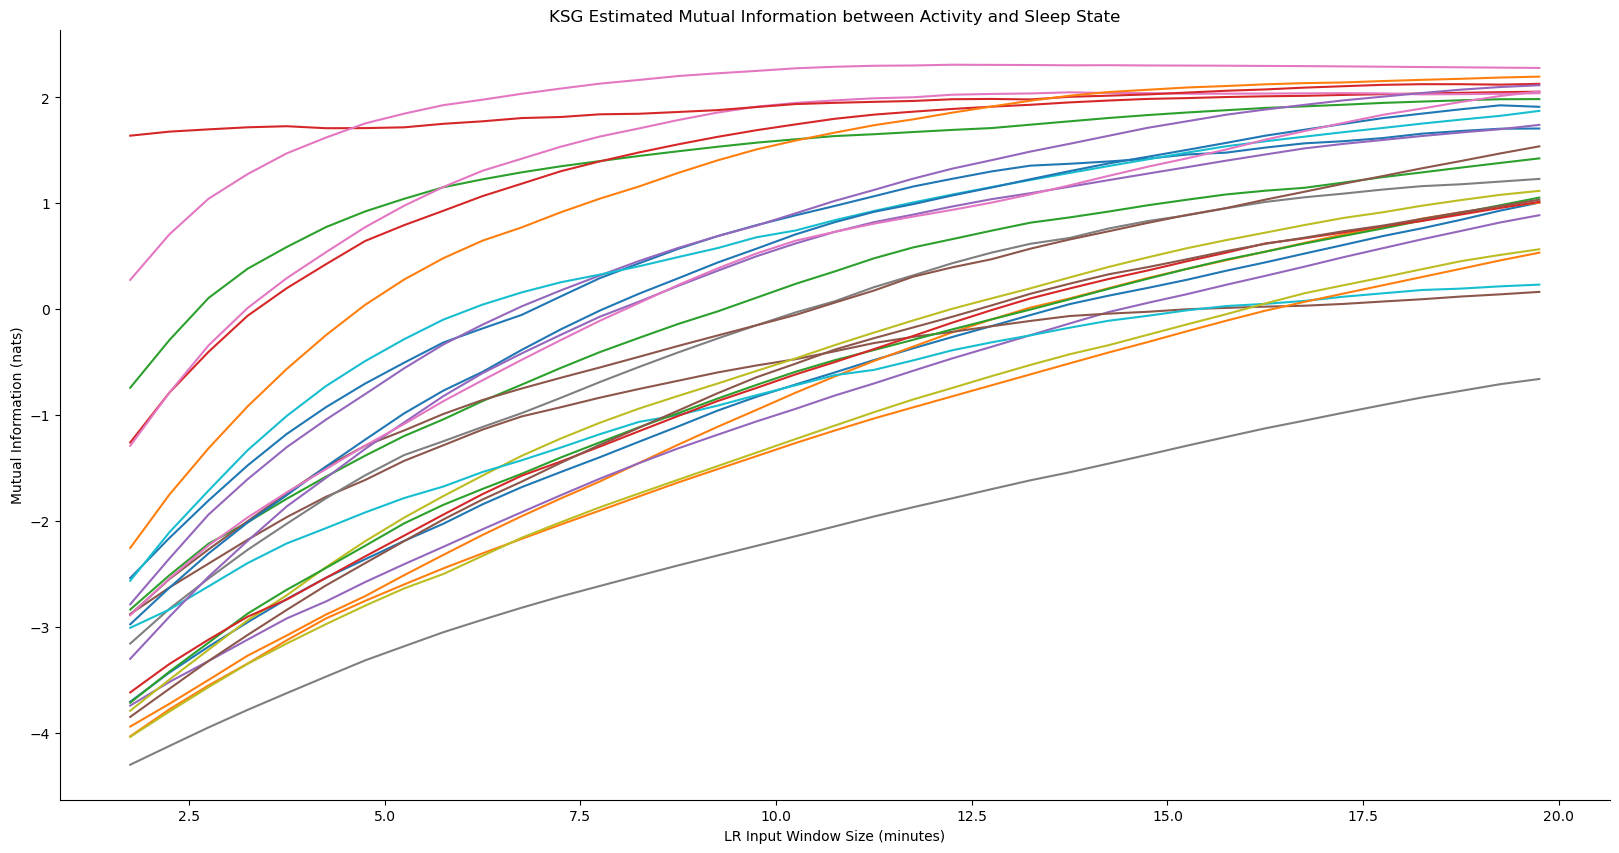

In [101]:
stdizer = StandardScaler()
window_sizes = np.arange(7, 81, 2)

plt.figure(figsize=(20, 10))
window_minutes = window_sizes * 15 / 60
for idx, sub_id in enumerate(walch.ids):
    window_results = []
    all_good = True
    for window_size in window_sizes:
        try:
            acc = walch.get_feature_data('accelerometer', sub_id)
            psg = walch.get_feature_data('psg', sub_id)
            activity_time, activity = build_ADS(acc, resample_hz=50, bin_size_seconds=30)
            activity_01 = stretch_to_range(activity, 0, 1)

            sw_psg = np.where(psg[:, 1] > 0, 1, psg[:, 1])

            wrapped_activity, wrapped_psg = wrap_io(activity_01, sw_psg, window_size)
            mi = mutual_information_ksg(wrapped_activity, wrapped_psg.reshape(-1, 1), k=5)
            window_results.append(mi)
        except Exception as e:
            if all_good:
                # print once per failure
                print(window_size, sub_id)
                all_good = False
            window_results.append(0)
            break
    
    if all_good:
        plt.plot(window_minutes, window_results, label=sub_id)
    

plt.xlabel('LR Input Window Size (minutes)')
plt.ylabel('Mutual Information (nats)')

# plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title('KSG Estimated Mutual Information between Activity and Sleep State')
plt.show()

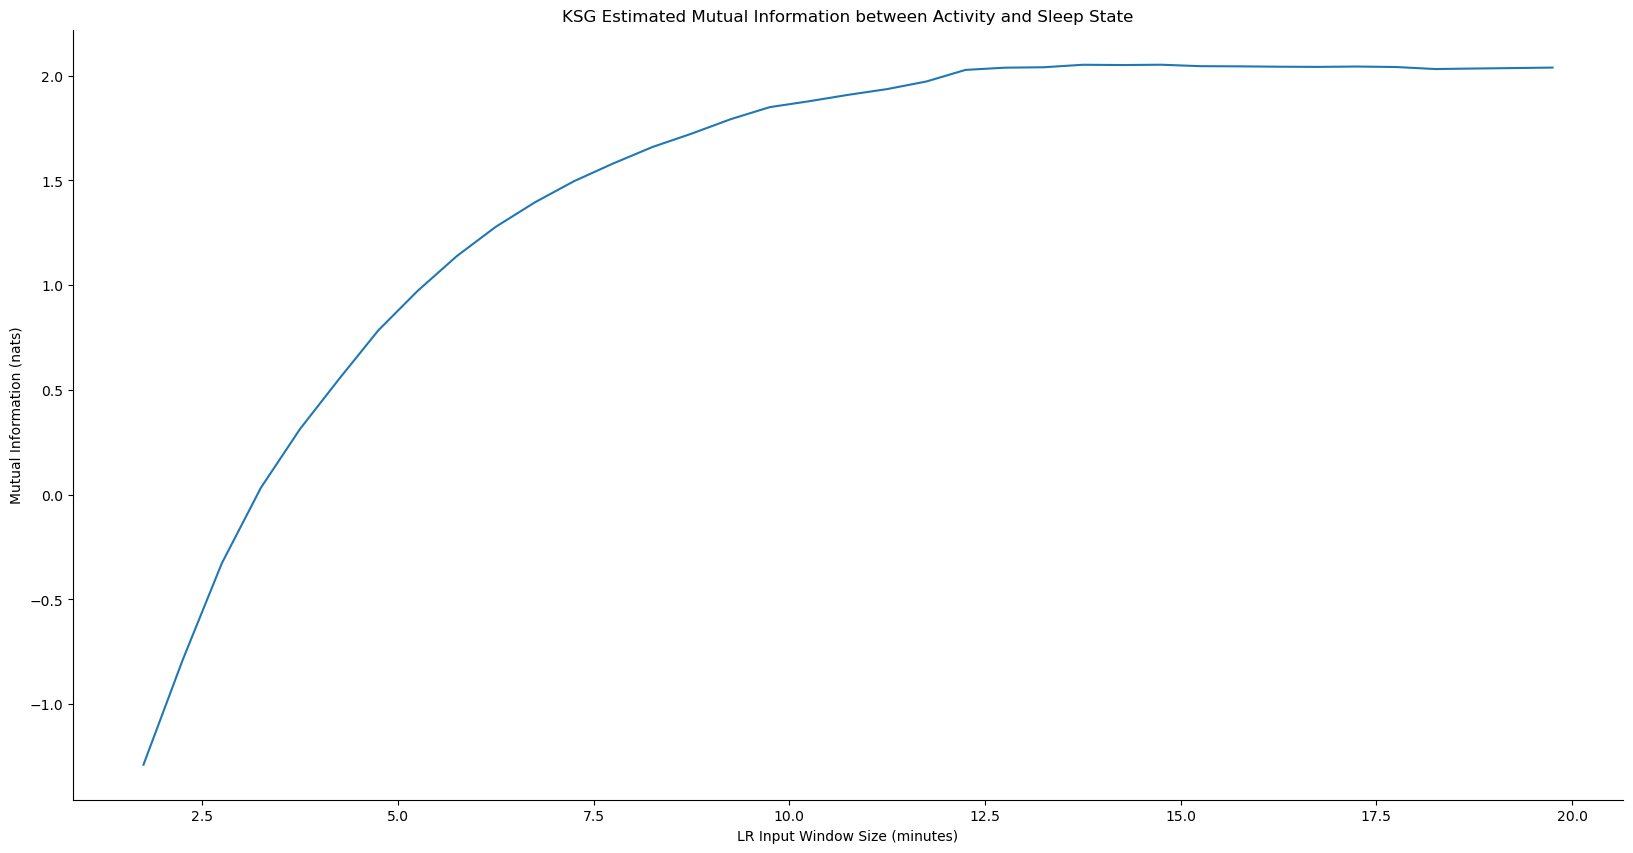

1. Raw activity counts feature => one theoretical limit
2. Juiced activity (add circadian + homeostatic) => another higher theoretical limit

Useful for Navy 
- generate fake data driven by noisy 2 process model
- are we getting more information from the juiced activity?